# 인물사진 만들기

In [2]:
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print(cv2.__version__)

4.11.0


### 1. 아웃포커싱 인물모드

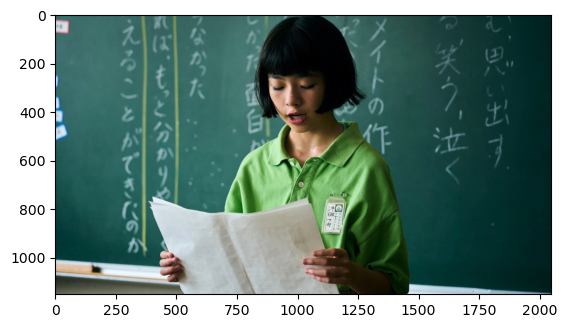

In [100]:
img_path = 'class.jpg'
img_orig = cv2.imread(img_path)
img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

plt.imshow(img_orig)
plt.show()

In [115]:
model = deeplabv3_resnet101(pretrained=True).eval()

preprocess = T.Compose([
    T.ToPILImage(),
    T.Resize(520),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img_orig).unsqueeze(0)

#사진에서 사람찾기
with torch.no_grad():
    output = model(input_tensor)['out'][0]
    # 각 픽셀마다 어떤 물체인지 번호 매기기
    seg_map = output.argmax(0).byte().cpu().numpy()

In [102]:
%%time
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

# 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (img_orig.shape[1], img_orig.shape[0]), interpolation=cv2.INTER_NEAREST)

CPU times: user 16.4 s, sys: 227 ms, total: 16.7 s
Wall time: 16.8 s


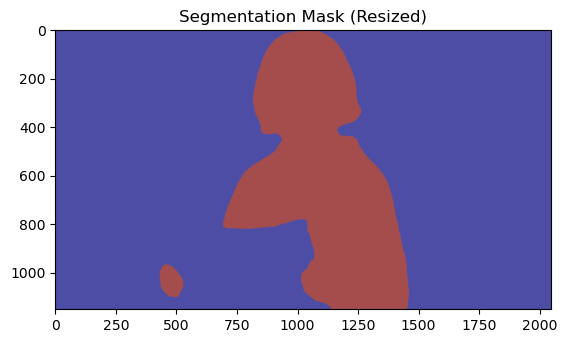

In [103]:
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

In [104]:
unique_classes = np.unique(output_predictions_resized)
unique_classes

array([ 0, 15], dtype=uint8)

In [105]:
for class_id in unique_classes:
    print(LABEL_NAMES[class_id])

background
person


In [116]:
#컬러맵 만들기
colormap = np.zeros((256, 3), dtype=int)
ind = np.arange(256, dtype=int)

for shift in reversed(range(8)):
    for channel in range(3):
        colormap[:, channel] |= ((ind >> channel) & 1) << shift
    ind >>= 3

colormap[:20]  # 생성한 20개의 컬러맵 출력

array([[  0,   0,   0],
       [128,   0,   0],
       [  0, 128,   0],
       [128, 128,   0],
       [  0,   0, 128],
       [128,   0, 128],
       [  0, 128, 128],
       [128, 128, 128],
       [ 64,   0,   0],
       [192,   0,   0],
       [ 64, 128,   0],
       [192, 128,   0],
       [ 64,   0, 128],
       [192,   0, 128],
       [ 64, 128, 128],
       [192, 128, 128],
       [  0,  64,   0],
       [128,  64,   0],
       [  0, 192,   0],
       [128, 192,   0]])

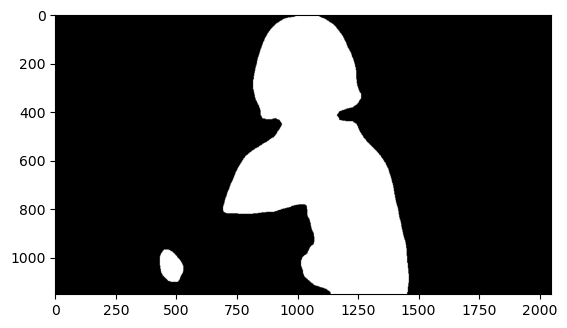

In [128]:
seg_map = (output_predictions_resized == 15)  
img_mask = seg_map.astype(np.uint8) * 255 
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

plt.imshow(img_mask, cmap='gray')  # 흑백으로 표시
plt.show()

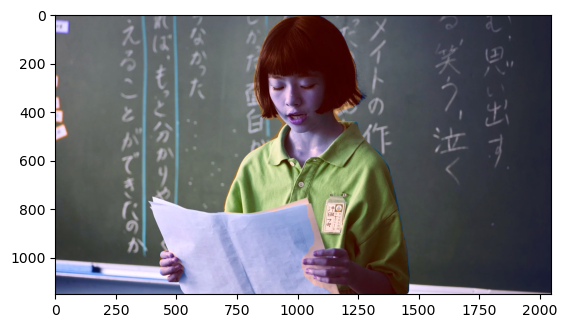

In [186]:
# 원본 이미지와 마스트를 적당히 합쳐봅니다
img_show = cv2.addWeighted(img_orig, 1, color_mask, 0.4, 0.0)

plt.imshow(cv2.cvtColor(img_show,cv2.COLOR_BGR2RGB))
plt.show()

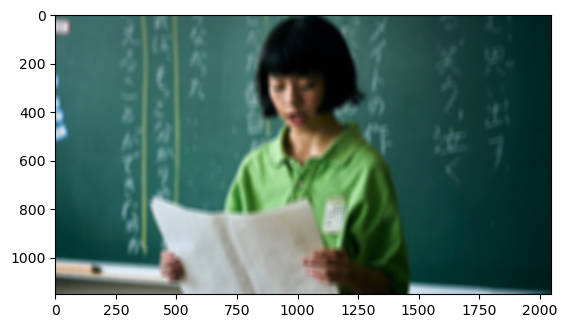

In [189]:
img_orig_blur = cv2.blur(img_orig, (20, 30))

plt.imshow(img_orig_blur)
plt.show()

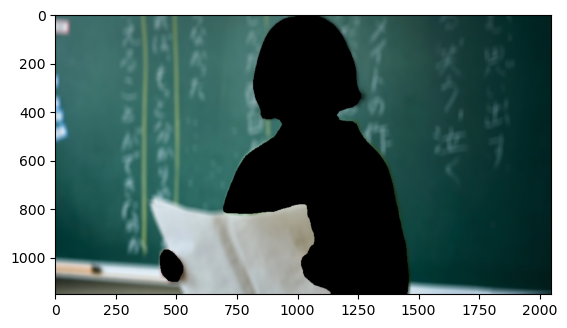

In [190]:
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

# cv2.bitwise_not(): 이미지가 반전됩니다. 배경이 0 사람이 255 였으나
# 연산을 하고 나면 배경은 255 사람은 0입니다.
img_bg_mask = cv2.bitwise_not(img_mask_color)

# cv2.bitwise_and()을 사용하면 배경만 있는 영상을 얻을 수 있습니다.
# 0과 어떤 수를 bitwise_and 연산을 해도 0이 되기 때문에
# 사람이 0인 경우에는 사람이 있던 모든 픽셀이 0이 됩니다. 결국 사람이 사라지고 배경만 남아요!
img_bg_blur = cv2.bitwise_and(img_orig_blur, img_bg_mask)
plt.imshow(img_bg_blur)
plt.show()

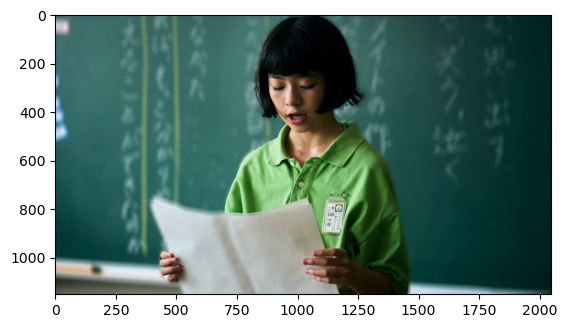

In [191]:
# np.where(조건, 참일때, 거짓일때)
# 세그멘테이션 마스크가 255인 부분만 원본 이미지 값을 가지고 오고 아닌 영역은 블러된 이미지 값을 사용합니다.
img_concat = np.where(img_mask_color==255, img_orig, img_bg_blur)
plt.imshow(img_concat)
plt.show()

### 2. 아웃포커싱 동물

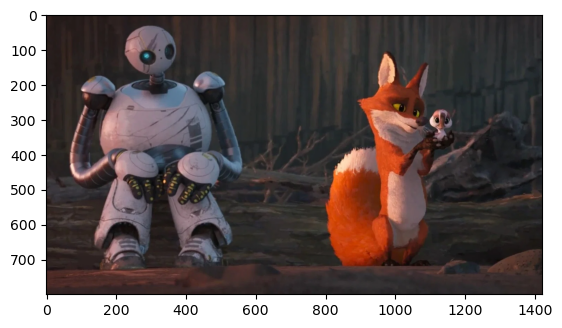

In [199]:
img_path = 'fox.jpg'
img_orig1 = cv2.imread(img_path)
img_orig1 = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

plt.imshow(img_orig)
plt.show()

In [206]:
model = deeplabv3_resnet101(pretrained=True).eval()

preprocess = T.Compose([
    T.ToPILImage(),
    T.Resize(520),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img_orig1).unsqueeze(0)

#사진에서 사람찾기
with torch.no_grad():
    output = model(input_tensor)['out'][0]
    # 각 픽셀마다 어떤 물체인지 번호 매기기
    seg_map = output.argmax(0).byte().cpu().numpy()

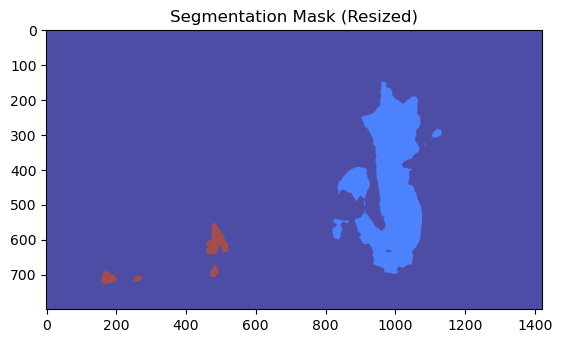

In [207]:
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

In [208]:
unique_classes = np.unique(output_predictions_resized)
unique_classes

array([ 0,  3, 15], dtype=uint8)

In [209]:
for class_id in unique_classes:
    print(LABEL_NAMES[class_id])

background
bird
person


?? 애니메이션 영화 사진이라 그런지 여우를 새?로 인식하는 건가?? 신기하네


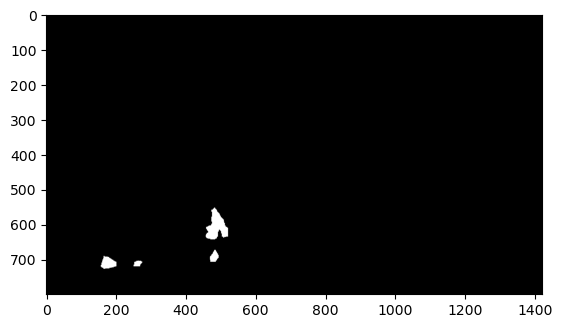

In [217]:
seg_map = (output_predictions_resized == 15)  
img_mask = seg_map.astype(np.uint8) * 255 
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

plt.imshow(img_mask, cmap='gray') 
plt.show()

로봇발?을 사람이라고 하는게 신기하다 왜 그렇지? 암튼 여우는 새로 인식되서 이걸로 아웃포커싱 해보자

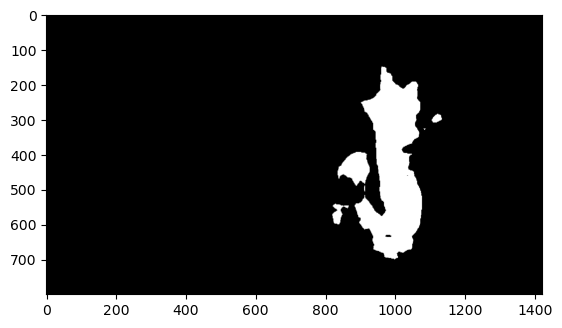

In [244]:
seg_map = (output_predictions_resized == 3)  
img_mask = seg_map.astype(np.uint8) * 255 
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

plt.imshow(img_mask, cmap='gray') 
plt.show()

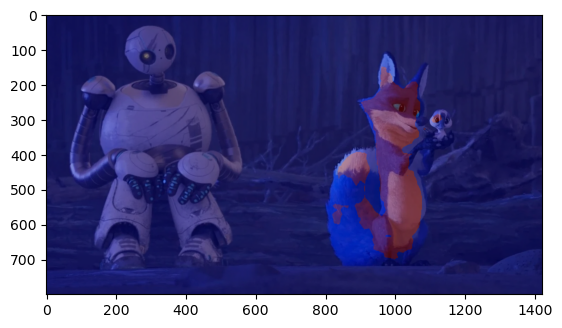

In [245]:
img_show = cv2.addWeighted(img_orig, 0.6, color_mask, 0.5, 0.0)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

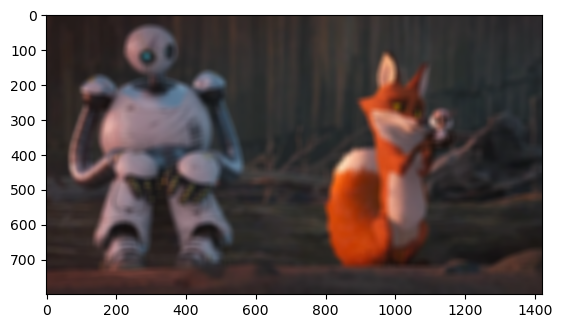

In [246]:
# 블러 넣어주기
img_orig_blur = cv2.blur(img_orig, (20,20))

plt.imshow(img_orig_blur)
plt.show()

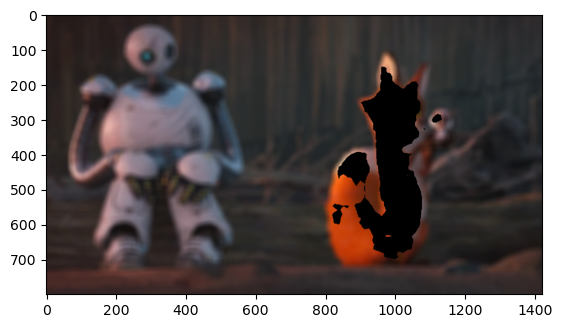

In [254]:
# 
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

img_bg_mask = cv2.bitwise_not(img_mask_color)

img_bg_blur = cv2.bitwise_and(img_orig_blur, img_bg_mask)
plt.imshow(img_bg_blur)
plt.show()

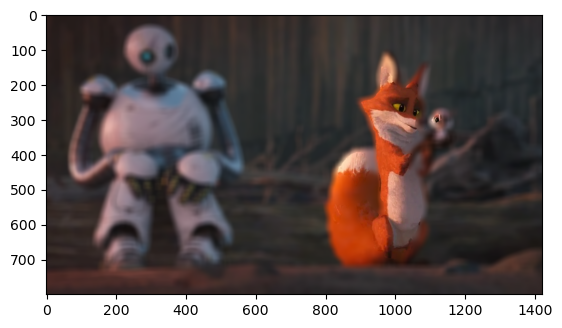

In [258]:
img_concat = np.where(img_mask_color==255, img_orig, img_bg_blur)

plt.imshow(img_concat)
plt.show()

꼬리부분이 제대로 누끼가 안따졌지만 그래도 얼굴있는 부분을 위주로는 된 것 같다.

###  배경전환

원본 사람 이미지 크기: (1080, 1920, 3)
배경(바다) 이미지 크기: (552, 1024, 3)


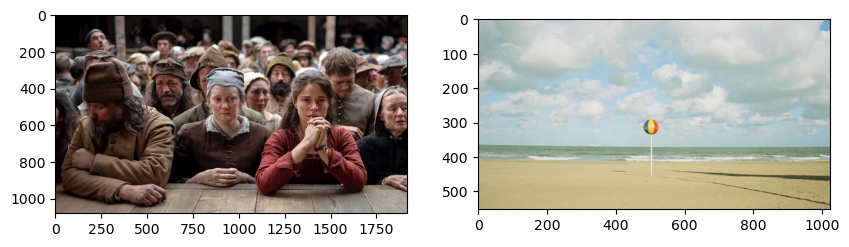

In [34]:
# 이미지 가져오기
person_img_path = "img1.jpg"  
beach_img_path = "beach.jpg"  

person_img = cv2.imread(person_img_path)
beach_img = cv2.imread(beach_img_path)

# openCV는 색깔을 BGR순서로 읽으니까 RGB로 순서 바꿔주기
person_img = cv2.cvtColor(person_img, cv2.COLOR_BGR2RGB)
beach_img = cv2.cvtColor(beach_img, cv2.COLOR_BGR2RGB)

print(f"원본 사람 이미지 크기: {person_img.shape}")
print(f"배경(바다) 이미지 크기: {beach_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(person_img)

plt.subplot(1, 2, 2)
plt.imshow(beach_img)

plt.show()

In [40]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(person_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0] #이사진에 뭐가 어디 있는지 번호표 붙이기
    output_predictions = output.argmax(0).byte().cpu().numpy() 

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

추론 마스크 크기 (Before Resize): (520, 520)


In [41]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (person_img.shape[1], person_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (1080, 1920)


In [42]:
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [ 0 15]


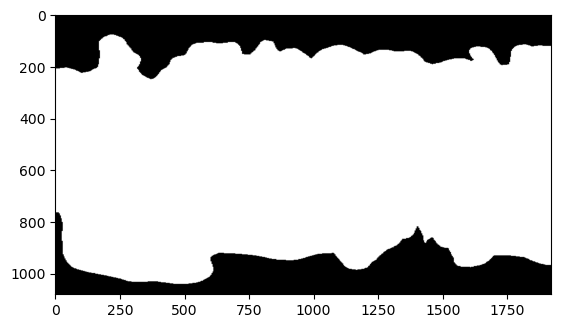

In [48]:
# 사람만 골라내기
target_class_id = 15

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

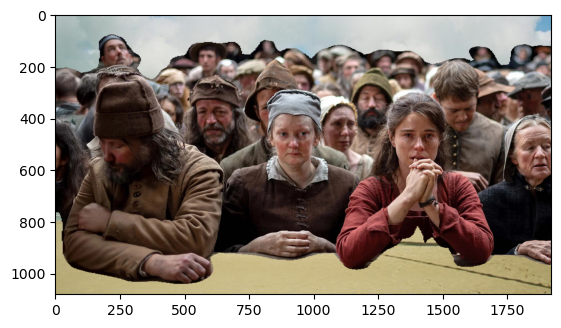

In [49]:
beach_img_resized = cv2.resize(beach_img, (person_img.shape[1], person_img.shape[0]))

img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, person_img, beach_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

많은 사람이 뭉쳐있는 경우 그 사람들 무리가 한덩어리로 인식되는 문제발생

### 1-1 인물모드 (2사람일때)

원본 사람2 이미지 크기: (2160, 3840, 3)
배경(바다) 이미지 크기: (552, 1024, 3)


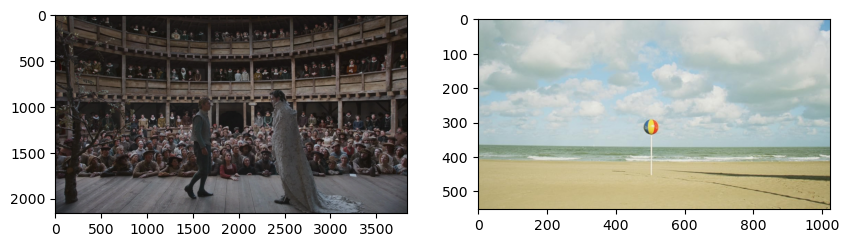

In [58]:
# 이미지 가져오기
person2_img_path = "person2.jpg"  
beach_img_path = "beach.jpg"  

person2_img = cv2.imread(person2_img_path)
beach_img = cv2.imread(beach_img_path)

# openCV는 색깔을 BGR순서로 읽으니까 RGB로 순서 바꿔주기
person2_img = cv2.cvtColor(person2_img, cv2.COLOR_BGR2RGB)
beach_img = cv2.cvtColor(beach_img, cv2.COLOR_BGR2RGB)

print(f"원본 사람2 이미지 크기: {person2_img.shape}")
print(f"배경(바다) 이미지 크기: {beach_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(person2_img)

plt.subplot(1, 2, 2)
plt.imshow(beach_img)

plt.show()

In [59]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(person2_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0] #이사진에 뭐가 어디 있는지 번호표 붙이기
    output_predictions = output.argmax(0).byte().cpu().numpy() 

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (person2_img.shape[1], person2_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

추론 마스크 크기 (Before Resize): (520, 520)
추론 마스크 크기 (After Resize): (2160, 3840)
예측된 클래스 ID: [ 0 15]


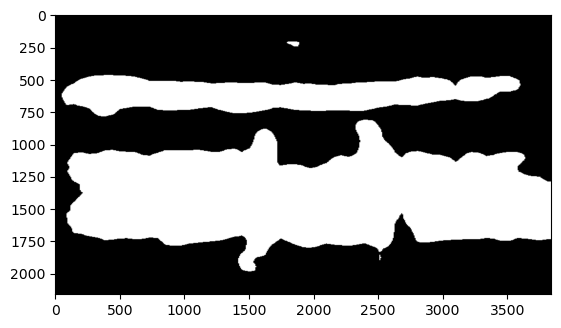

In [60]:
# 사람만 골라내기
target_class_id = 15

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

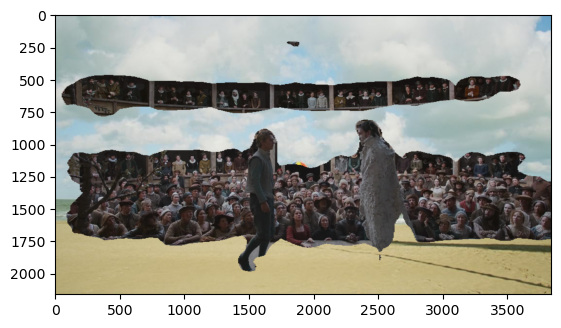

In [62]:
beach_img_resized = cv2.resize(beach_img, (person2_img.shape[1], person2_img.shape[0]))

img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, person2_img, beach_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

두사람이 무대 앞에 있어도 관객석의 사람도 같이 잡혀서 이상하게 합성됨. 실패!!

### 1-3 한 사람만 있는 인물모드
이건 되겠지

원본 사람3 이미지 크기: (218, 293, 3)
배경(바다) 이미지 크기: (552, 1024, 3)


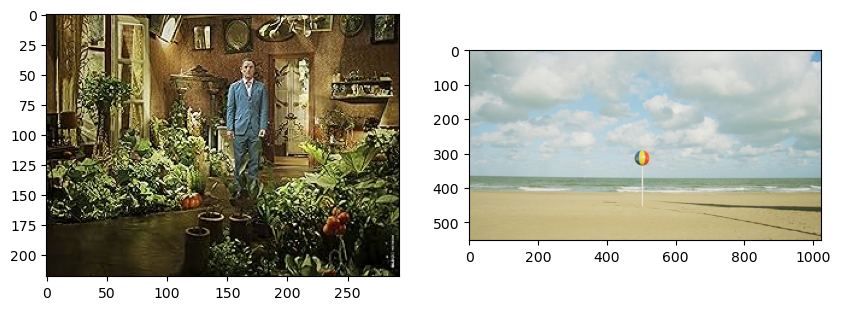

In [66]:
# 이미지 가져오기
person3_img_path = "person3.jpg"  
beach_img_path = "beach.jpg"  

person3_img = cv2.imread(person3_img_path)
beach_img = cv2.imread(beach_img_path)

# openCV는 색깔을 BGR순서로 읽으니까 RGB로 순서 바꿔주기
person3_img = cv2.cvtColor(person3_img, cv2.COLOR_BGR2RGB)
beach_img = cv2.cvtColor(beach_img, cv2.COLOR_BGR2RGB)

print(f"원본 사람3 이미지 크기: {person3_img.shape}")
print(f"배경(바다) 이미지 크기: {beach_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(person3_img)

plt.subplot(1, 2, 2)
plt.imshow(beach_img)

plt.show()

In [72]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(person3_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0] #이사진에 뭐가 어디 있는지 번호표 붙이기
    output_predictions = output.argmax(0).byte().cpu().numpy() 

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (person3_img.shape[1], person3_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

추론 마스크 크기 (Before Resize): (520, 520)
추론 마스크 크기 (After Resize): (218, 293)
예측된 클래스 ID: [ 0 11 15 16]


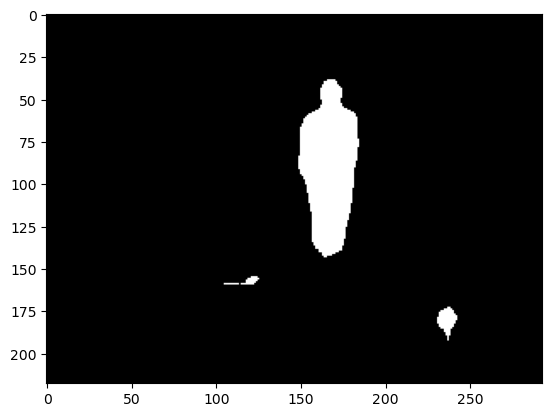

In [73]:
# 사람만 골라내기
target_class_id = 15

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

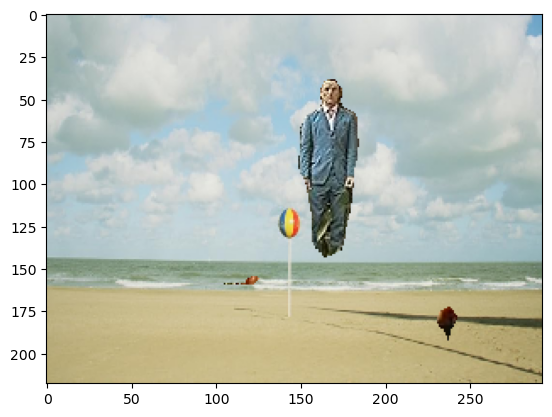

In [74]:
beach_img_resized = cv2.resize(beach_img, (person3_img.shape[1], person3_img.shape[0]))

img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, person3_img, beach_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

어색하지만 한사람만 있는건 되긴함. (오른쪽에는 왜 인식이 된걸까?)

### 회고

처음에 노드학습에 있는 코드 그대로 하니까 배경부분 색이 오히려 이상해서 cv2.COLOR_BGR2RGB을 안해도 되는 부분은 삭제하면서 실습 해보았습니다. 
그리고 동물 사진으로 했을때 개나 고양이가 아니라 분류에 없는 것들 위에서 한 여우 캐릭터가 bird로 분류되는 것 처럼 분류자체가 어려운 개체는 다른 방식으로 써야되겠다고 생각했습니다.

그리고 사람인식을 생각보다 너무 잘 해서 그런지 눈코입이 또렸히 잘보이는 사람외에도 관객같이 작게 저 멀리 있는 사람들도 인식해서 마스킹이 잘 되었습니다.

예전에 포토샵이나 일러로 이런것들을 해봤는데 코딩으로 하려니 이런 순서로 진행되는걸 알게되어서 재밌었습니다.

잘 인식이 안되거나 그런 부분에 있어서 아직 해결방안을 찾지는 못해서 따로 찾아보려고 합니다.